In [12]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 90,
    "double": 180,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 600,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


正在处理: $\mathrm{IDP}_{50}$ (Row 1)
  -> [加载缓存] alhx_0.txt
  -> [加载缓存] alhx_0_re1.txt
  -> [加载缓存] alhx_0_re2.txt
正在处理: $\mathrm{Hel}_{50}$ (Row 2)
  -> [加载缓存] alhx_700.txt
  -> [加载缓存] alhx_700_re1.txt
  -> [加载缓存] alhx_700_re2.txt
绘图完成！图片已保存至: comparison_6_panels_nature_style.png


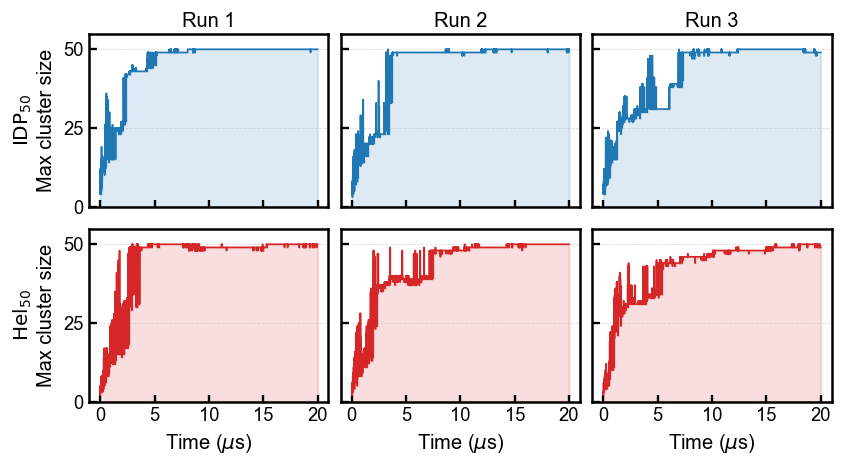

In [13]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.lib.distances import distance_array
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys
import os

# ================= 用户参数设置 =================
# 只改这里：在 single_small / single_medium / double_short / double_medium / double_large 中切换
FIG_PRESET = "double_medium"

# --- 组1配置 ---
GROUP_1_NAME = r"$\mathrm{IDP}_{50}$"
GROUP_1_COLOR = "#1f77b4"  # 蓝色
GROUP_1_FILES = [
    # 请确保 'save_name' 指向你硬盘上已经存在的 .txt 文件
    {'tpr': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.tpr',
    'xtc': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0/TR_Mdvwhole/pbc.xtc',
    'save_name': 'alhx_0.txt'}, 
    {'tpr': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/pbc.tpr',
    'xtc': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re1/TR_Mdvwhole/pbc.xtc',
    'save_name': 'alhx_0_re1.txt'},
    {'tpr': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/pbc.tpr',
    'xtc': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_0_re2/TR_Mdvwhole/pbc.xtc',
    'save_name': 'alhx_0_re2.txt'},
]

# --- 组2配置 ---
GROUP_2_NAME = r"$\mathrm{Hel}_{50}$"
GROUP_2_COLOR = "#d62728"  # 红色
GROUP_2_FILES = [
    {'tpr': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.tpr',
    'xtc': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700/TR_Mdvwhole/pbc.xtc',
    'save_name': 'alhx_700.txt'},
    {'tpr': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/pbc.tpr',
    'xtc': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re1/TR_Mdvwhole/pbc.xtc',
    'save_name': 'alhx_700_re1.txt'},
    {'tpr': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/pbc.tpr',
    'xtc': '/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/W_cluster/alhx_700_re2/TR_Mdvwhole/pbc.xtc',
    'save_name': 'alhx_700_re2.txt'},
]

# --- 分析参数 ---
START_FRAME = 0          
END_FRAME = -1           
STRIDE = 1               
CUTOFF_DISTANCE = 8.0            
SELECTION_CRITERIA = 'protein and name BB' 

# ==============================================

def find_clusters(adj_matrix):
    """BFS查找连通分量"""
    n = len(adj_matrix)
    visited = np.zeros(n, dtype=bool)
    clusters = []
    for i in range(n):
        if not visited[i]:
            cluster = []
            q = [i]
            visited[i] = True
            while q:
                cur = q.pop(0)
                cluster.append(cur)
                for v in range(n):
                    if adj_matrix[cur, v] and not visited[v]:
                        visited[v] = True
                        q.append(v)
            clusters.append(cluster)
    return clusters

def analyze_single_trajectory(tpr, xtc, save_file):
    """
    分析单条轨迹，返回 (Time [us], Max_Size)
    逻辑：
    1. 如果文件存在，读取并假设它是 ns，除以 1000 变 us。
    2. 如果文件不存在，计算 (保存为 ns)，返回时除以 1000 变 us。
    """
    # ----------------------------------------------------
    # 1. 尝试直接加载现有文件 (无需重新计算)
    # ----------------------------------------------------
    if os.path.exists(save_file):
        print(f"  -> [加载缓存] {save_file}")
        try:
            data = np.loadtxt(save_file)
            if data.ndim == 1: data = data.reshape(1, -1)
            
            time_ns = data[:, 0]
            size_vals = data[:, 1]
            
            # 【关键】在此处进行单位转换：ns -> us
            time_us = time_ns / 1000.0 
            
            return time_us, size_vals
        except Exception as e:
            print(f"    读取失败 ({e})，准备重新计算...")

    # ----------------------------------------------------
    # 2. 如果文件不存在，进行计算
    # ----------------------------------------------------
    print(f"  -> [开始计算] {os.path.basename(xtc)}")
    try:
        u = mda.Universe(tpr, xtc)
    except Exception as e:
        print(f"    错误: 无法加载 {xtc}。{e}")
        return None, None

    if END_FRAME == -1: traj = u.trajectory[START_FRAME::STRIDE]
    else: traj = u.trajectory[START_FRAME:END_FRAME:STRIDE]

    # === 修正：使用 fragments 确保 50 条链被正确识别 ===
    protein_chains = u.select_atoms('protein').fragments
    if len(protein_chains) > 50:
         protein_chains = [c for c in protein_chains if len(c) > 10]
    num_chains = len(protein_chains)
    
    chain_selections = [c.select_atoms(SELECTION_CRITERIA) for c in protein_chains]
    
    times_ns = [] # 存储为 ns
    sizes = []
    n_frames = len(traj)

    for i, ts in enumerate(traj):
        adj = np.zeros((num_chains, num_chains), dtype=bool)
        for c1 in range(num_chains):
            pos1 = chain_selections[c1].positions
            for c2 in range(c1 + 1, num_chains):
                pos2 = chain_selections[c2].positions
                if np.any(distance_array(pos1, pos2) < CUTOFF_DISTANCE):
                    adj[c1, c2] = adj[c2, c1] = True
        
        clusters = find_clusters(adj)
        max_s = len(max(clusters, key=len)) if clusters else 0
        
        # MDAnalysis ts.time 是 ps，除以 1000 变成 ns
        times_ns.append(ts.time / 1000.0) 
        sizes.append(max_s)
        
        if i % 100 == 0:
            sys.stdout.write(f"\r    Frame {i}/{n_frames} | Size: {max_s}")
            sys.stdout.flush()
    
    print("") 
    
    times_ns = np.array(times_ns)
    sizes = np.array(sizes)
    
    # 保存时保持 ns (标准单位)，方便以后复用
    save_data = np.column_stack((times_ns, sizes))
    np.savetxt(save_file, save_data, fmt="%.4f", header="Time(ns) Max_Cluster_Size")
    
    # 返回时转换为 us 用于绘图
    return times_ns / 1000.0, sizes

def main():
    # 使用上面统一位置的尺寸预设
    mode_width, mode_height = FIG_PRESETS[FIG_PRESET]
    fig_width_mm = FIG_SIZE[mode_width]
    fig_height_mm = mode_height
    
    fig, axes = plt.subplots(2, 3, figsize=(mm_to_inch(fig_width_mm), mm_to_inch(fig_height_mm)),
                             sharex=True, sharey=True)

    groups = [
        {'name': GROUP_1_NAME, 'files': GROUP_1_FILES, 'color': GROUP_1_COLOR, 'row_idx': 0},
        {'name': GROUP_2_NAME, 'files': GROUP_2_FILES, 'color': GROUP_2_COLOR, 'row_idx': 1}
    ]

    print("="*60)
    for group in groups:
        row       = group['row_idx']
        color     = group['color']
        files     = group['files']
        group_name = group['name']

        print(f"正在处理: {group_name} (Row {row+1})")

        for col, item in enumerate(files):
            ax = axes[row, col]
            t, s = analyze_single_trajectory(item['tpr'], item['xtc'], item['save_name'])

            if t is not None:
                ax.plot(t, s, color=color, linewidth=1.0)
                ax.fill_between(t, 0, s, color=color, alpha=0.15)
                ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

            # 上轴和右轴不显示刻度
            ax.tick_params(top=False, right=False)

            # X 轴主刻度：每 5 µs 一格（可按实际时间范围调整）
            ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

            # Y 轴主刻度：每 25 链一格，显示 0/25/50
            ax.yaxis.set_major_locator(ticker.MultipleLocator(25))

            # 确保次刻度全部关闭
            ax.minorticks_off()

    # ── 坐标轴标签 ───────────────────────────────────────────
    for row_idx, g_name in enumerate([GROUP_1_NAME, GROUP_2_NAME]):
        axes[row_idx, 0].set_ylabel(f"{g_name}\nMax cluster size", fontsize=mpl.rcParams['axes.labelsize'])

    for ax in axes[1, :]:
        ax.set_xlabel(r"Time ($\mu$s)", fontsize=mpl.rcParams['axes.labelsize'])

    # 列标题（Run 1/2/3）
    for col_idx, rep_label in enumerate(['Run 1', 'Run 2', 'Run 3']):
        axes[0, col_idx].set_title(rep_label, fontsize=mpl.rcParams['axes.titlesize'], pad=4)

    # Y 轴范围
    plt.ylim(0, 55)

    plt.tight_layout(pad=0.8, h_pad=0.6, w_pad=0.6)

    output_png = 'comparison_6_panels_nature_style.png'
    plt.savefig(output_png, dpi=600, bbox_inches='tight')
    print("="*60)
    print(f"绘图完成！图片已保存至: {output_png}")
    plt.show()

if __name__ == '__main__':
    main()


group,replicate,file,t_size_ge_25_us,t50_relative_us,early_linear_slope_0_5us,t_size_ge_40_us,late_full_occupancy_fraction,late_near_full_occupancy_fraction,late_mean_size,late_sd_size,late_fragmentation_events_lt_near_full,stable_ge_49_us
$\mathrm{IDP}_{50}$,Run 1,alhx_0.txt,1.896,2.269,8.020,2.480,1.000,1.000,50.000,0.010,0,5.216
$\mathrm{IDP}_{50}$,Run 2,alhx_0_re1.txt,3.034,3.366,9.033,3.568,0.775,0.998,49.773,0.424,10,10.348
$\mathrm{IDP}_{50}$,Run 3,alhx_0_re2.txt,1.424,3.838,5.344,6.917,0.614,0.998,49.612,0.491,11,19.615
$\mathrm{Hel}_{50}$,Run 1,alhx_700.txt,1.572,2.541,10.672,2.717,0.464,0.995,49.459,0.509,28,15.008
$\mathrm{Hel}_{50}$,Run 2,alhx_700_re1.txt,1.742,2.222,7.479,7.106,0.591,0.957,49.548,0.578,23,15.692
$\mathrm{Hel}_{50}$,Run 3,alhx_700_re2.txt,1.032,1.219,5.070,5.044,0.188,0.503,48.659,0.817,70,18.037


section,metric,label,$\mathrm{IDP}_{50}$_mean,$\mathrm{IDP}_{50}$_sd,$\mathrm{IDP}_{50}$_median,$\mathrm{Hel}_{50}$_mean,$\mathrm{Hel}_{50}$_sd,$\mathrm{Hel}_{50}$_median,delta_$\mathrm{Hel}_{50}$-$\mathrm{IDP}_{50}$,bootstrap_delta_2.5%,bootstrap_delta_97.5%,exact_perm_p,$\mathrm{IDP}_{50}$_n,$\mathrm{Hel}_{50}$_n
early_speed,t_size_ge_25_us,T25: time to Nmax >= 25,2.118,0.828,1.896,1.449,0.371,1.572,-0.669,-1.585,0.105,0.300,3,3
early_speed,t50_relative_us,t50 relative growth,3.158,0.805,3.366,1.994,0.690,2.222,-1.164,-2.127,-0.200,0.200,3,3
early_speed,early_linear_slope_0_5us,early slope 0-5 us,7.466,1.906,8.020,7.741,2.810,7.479,0.275,-2.822,3.372,1.000,3,3
early_speed,early_auc_fraction_0_5us,early AUC 0-5 us,0.586,0.065,0.567,0.588,0.042,0.571,0.002,-0.070,0.069,0.900,3,3
late_stability,late_full_occupancy_fraction,late P(Nmax = 50),0.796,0.194,0.775,0.415,0.206,0.464,-0.382,-0.645,-0.119,0.100,3,3
late_stability,late_near_full_occupancy_fraction,late P(Nmax >= 49),0.999,0.001,0.998,0.818,0.273,0.957,-0.181,-0.495,-0.004,0.100,3,3
late_stability,late_mean_size,late mean Nmax,49.795,0.195,49.773,49.222,0.490,49.459,-0.573,-1.083,-0.148,0.100,3,3
late_stability,late_sd_size,late SD of Nmax,0.308,0.260,0.424,0.635,0.161,0.578,0.326,0.064,0.625,0.100,3,3
late_stability,late_fragmentation_events_lt_near_full,late drops below 49,7.000,6.083,10.000,40.333,25.813,28.000,33.333,14.000,62.667,0.100,3,3
late_stability,stable_ge_49_us,sustained Nmax >= 49 from,11.726,7.298,10.348,16.246,1.589,15.692,4.519,-3.141,11.030,0.400,3,3


核心读图指标:
- Early T25: $\mathrm{IDP}_{50}$ 2.12 us, $\mathrm{Hel}_{50}$ 1.45 us.
- Last 10 us P(Nmax=50): $\mathrm{IDP}_{50}$ 79.6%, $\mathrm{Hel}_{50}$ 41.5%.
- Last 10 us SD(Nmax): $\mathrm{IDP}_{50}$ 0.31, $\mathrm{Hel}_{50}$ 0.63.
注意：每组只有 3 条 replica，permutation p-value 只能作为辅助参考。
结果已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/cluster_kinetics_metrics.csv
结果已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/cluster_early_late_summary.csv


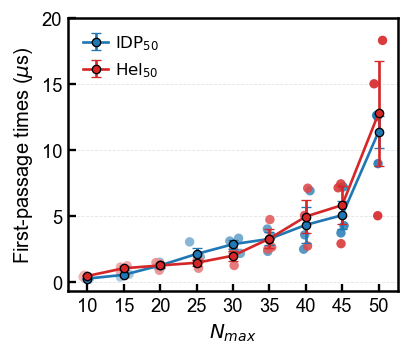

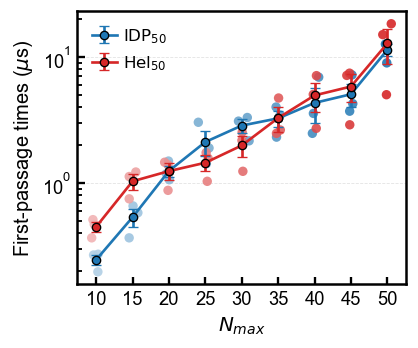

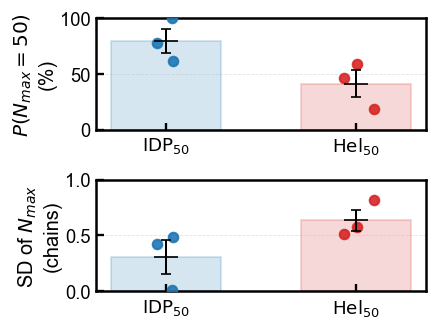

左图已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/cluster_kinetics_fpt_single.png
左图（log scale）已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/cluster_kinetics_fpt_single_log.png
右图已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/cluster_kinetics_late_two_panels_single_medium.png


In [14]:
# ================= 凝聚动力学：前期速度 + 后期稳定性 =================
# 运行前请先运行上面的 cell，保证 GROUP_1_FILES/GROUP_2_FILES 等变量已经定义。
# 默认优先读取已有 txt 缓存，不会重新跑 MDAnalysis，除非缓存文件找不到。

import csv
import html
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    from IPython.display import HTML,display
except Exception:
    HTML=None
    display=print

# ---------------- 用户可调参数 ----------------
KINETICS_TOTAL_CHAINS=50
KINETICS_SMOOTH_WINDOW_US=0.50
KINETICS_EARLY_WINDOW_US=5.0
KINETICS_LATE_WINDOW_US=10.0
KINETICS_HALF_CLUSTER_SIZE=25
KINETICS_LARGE_CLUSTER_SIZE=40
KINETICS_NEAR_FULL_SIZE=49
KINETICS_BOOTSTRAP_N=20000
KINETICS_RANDOM_SEED=20260517
FPT_THRESHOLDS=[10, 15, 20, 25, 30, 35, 40, 45, 50]
FPT_SMOOTH_WINDOW_US=0.50

KNOWN_LARGCLUS_DIR=Path('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus')


def _result_dir():
    candidates=[Path.cwd(),Path.cwd()/'Analysis/largclus',KNOWN_LARGCLUS_DIR]
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob('alhx_*.txt')):
            return candidate
    return Path.cwd()


RESULT_DIR=_result_dir()


def _resolve_cache_path(save_name):
    save_path=Path(save_name)
    candidates=[save_path,Path.cwd()/save_path,Path.cwd()/'Analysis/largclus'/save_path.name,KNOWN_LARGCLUS_DIR/save_path.name]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return RESULT_DIR/save_path.name


def _read_trace_file(path):
    data=np.loadtxt(path)
    if data.ndim==1:
        data=data.reshape(1,-1)

    first_line=path.read_text(errors='ignore').splitlines()[0] if path.exists() else ''
    time=data[:,0].astype(float)
    if 'Time(ns)' in first_line or np.nanmax(time)>100:
        time=time/1000.0

    size=data[:,1].astype(float)
    order=np.argsort(time)
    return time[order],size[order]


def load_cluster_trace(item):
    cache_path=_resolve_cache_path(item['save_name'])
    if cache_path.exists():
        t,size=_read_trace_file(cache_path)
        return t,size,cache_path

    print(f"缓存没找到，重新计算: {cache_path.name}")
    t,size=analyze_single_trajectory(item['tpr'],item['xtc'],str(cache_path))
    return t,size,cache_path


def smooth_by_time(time,values,window_us=0.5):
    time=np.asarray(time,dtype=float)
    values=np.asarray(values,dtype=float)
    if len(values)<3:
        return values.copy()

    dt=np.diff(time)
    dt=dt[np.isfinite(dt)&(dt>0)]
    if len(dt)==0:
        return values.copy()

    window=int(round(window_us/np.median(dt)))
    window=max(3,window)
    if window%2==0:
        window+=1
    if window>=len(values):
        window=len(values)-1 if len(values)%2==0 else len(values)
    if window<3:
        return values.copy()

    pad=window//2
    padded=np.pad(values,(pad,pad),mode='edge')
    kernel=np.ones(window,dtype=float)/window
    return np.convolve(padded,kernel,mode='valid')


def first_crossing_time(time,values,threshold):
    time=np.asarray(time,dtype=float)
    values=np.asarray(values,dtype=float)
    hits=np.flatnonzero(values>=threshold)
    if len(hits)==0:
        return np.nan

    idx=int(hits[0])
    if idx==0:
        return float(time[0])

    t0,t1=time[idx-1],time[idx]
    y0,y1=values[idx-1],values[idx]
    if y1==y0:
        return float(t1)
    return float(t0+(threshold-y0)*(t1-t0)/(y1-y0))


def smooth_fpt_by_time(time,values,window_us):
    time=np.asarray(time,dtype=float)
    values=np.asarray(values,dtype=float)
    if len(time)<2 or window_us<=0:
        return values
    dt=np.median(np.diff(time))
    if not np.isfinite(dt) or dt<=0:
        return values
    win=max(1,int(round(window_us/dt)))
    kernel=np.ones(win,dtype=float)/win
    return np.convolve(values,kernel,mode='same')


def fpt_first_crossing_time(time,values,threshold):
    time=np.asarray(time,dtype=float)
    values=np.asarray(values,dtype=float)
    idx=np.where(values>=threshold)[0]
    return time[idx[0]] if len(idx) else np.nan


def sustained_cluster_time(time,values,threshold):
    time=np.asarray(time,dtype=float)
    values=np.asarray(values,dtype=float)
    below=np.flatnonzero(values<threshold)
    if len(below)==0:
        return float(time[0])

    last_below=int(below[-1])
    if last_below>=len(values)-1:
        return np.nan

    return float(time[last_below+1])


def count_late_fragmentation_events(time,values,threshold,late_start):
    time=np.asarray(time,dtype=float)
    values=np.asarray(values,dtype=float)
    mask=time>=late_start
    late_values=values[mask]
    if len(late_values)<2:
        return np.nan

    was_near_full=late_values[:-1]>=threshold
    drops_below=late_values[1:]<threshold
    return int(np.sum(was_near_full&drops_below))


def early_auc_fraction(time,values,total_chains,window_us):
    start=float(time[0])
    stop=min(start+window_us,float(time[-1]))
    if stop<=start:
        return np.nan

    mask=(time>=start)&(time<=stop)
    t_auc=time[mask]
    y_auc=values[mask]

    if len(t_auc)==0 or t_auc[0]>start:
        y_start=np.interp(start,time,values)
        t_auc=np.insert(t_auc,0,start)
        y_auc=np.insert(y_auc,0,y_start)

    if t_auc[-1]<stop:
        y_stop=np.interp(stop,time,values)
        t_auc=np.append(t_auc,stop)
        y_auc=np.append(y_auc,y_stop)

    trapezoid=getattr(np,'trapezoid',np.trapz)
    return float(trapezoid(y_auc/total_chains,t_auc)/(stop-start))


def linear_slope(time,values,window_us):
    stop=min(float(time[0])+window_us,float(time[-1]))
    mask=(time>=time[0])&(time<=stop)
    if np.sum(mask)<2:
        return np.nan

    slope,intercept=np.polyfit(time[mask],values[mask],1)
    return float(slope)


def trace_kinetics(time,size):
    time=np.asarray(time,dtype=float)
    size=np.asarray(size,dtype=float)
    finite=np.isfinite(time)&np.isfinite(size)
    time,size=time[finite],size[finite]
    order=np.argsort(time)
    time,size=time[order],size[order]

    smoothed=smooth_by_time(time,size,KINETICS_SMOOTH_WINDOW_US)
    n=len(smoothed)
    n_start=max(3,int(np.ceil(0.05*n)))
    n_end=max(3,int(np.ceil(0.20*n)))

    baseline=float(np.nanmedian(smoothed[:n_start]))
    plateau=float(np.nanmedian(smoothed[-n_end:]))
    amplitude=plateau-baseline
    late_start=max(float(time[0]),float(time[-1])-KINETICS_LATE_WINDOW_US)
    late_mask=time>=late_start
    late_size=size[late_mask]

    metrics={
        'baseline_size':baseline,
        'plateau_size':plateau,
        'amplitude_size':amplitude,
        'observed_max_size':float(np.nanmax(size)),
        'late_window_start_us':late_start,
        'late_window_end_us':float(time[-1]),
    }

    for frac in (0.10,0.50,0.80):
        key=f't{int(frac*100)}_relative_us'
        if amplitude>1e-6:
            threshold=baseline+frac*amplitude
            metrics[key]=first_crossing_time(time,smoothed,threshold)
        else:
            metrics[key]=np.nan

    metrics['growth_duration_t10_to_t80_us']=metrics['t80_relative_us']-metrics['t10_relative_us']

    for threshold in (KINETICS_HALF_CLUSTER_SIZE,KINETICS_LARGE_CLUSTER_SIZE):
        metrics[f't_size_ge_{threshold}_us']=first_crossing_time(time,smoothed,threshold)

    slope=np.gradient(smoothed,time)
    metrics['max_slope_chains_per_us']=float(np.nanmax(slope))
    metrics[f'early_auc_fraction_0_{KINETICS_EARLY_WINDOW_US:g}us']=early_auc_fraction(time,smoothed,KINETICS_TOTAL_CHAINS,KINETICS_EARLY_WINDOW_US)
    metrics[f'early_linear_slope_0_{KINETICS_EARLY_WINDOW_US:g}us']=linear_slope(time,smoothed,KINETICS_EARLY_WINDOW_US)

    if len(late_size):
        metrics['late_mean_size']=float(np.nanmean(late_size))
        metrics['late_sd_size']=float(np.nanstd(late_size,ddof=1)) if len(late_size)>1 else 0.0
        metrics['late_full_occupancy_fraction']=float(np.mean(np.isclose(late_size,KINETICS_TOTAL_CHAINS)))
        metrics['late_near_full_occupancy_fraction']=float(np.mean(late_size>=KINETICS_NEAR_FULL_SIZE))
        metrics['late_escape_fraction_lt_near_full']=float(np.mean(late_size<KINETICS_NEAR_FULL_SIZE))
        metrics['late_fragmentation_events_lt_near_full']=count_late_fragmentation_events(time,size,KINETICS_NEAR_FULL_SIZE,late_start)
    else:
        metrics['late_mean_size']=np.nan
        metrics['late_sd_size']=np.nan
        metrics['late_full_occupancy_fraction']=np.nan
        metrics['late_near_full_occupancy_fraction']=np.nan
        metrics['late_escape_fraction_lt_near_full']=np.nan
        metrics['late_fragmentation_events_lt_near_full']=np.nan

    metrics[f'stable_ge_{KINETICS_NEAR_FULL_SIZE}_us']=sustained_cluster_time(time,size,KINETICS_NEAR_FULL_SIZE)
    return metrics


def finite_values(records,group_name,metric):
    values=[r[metric] for r in records if r['group']==group_name]
    return np.array([v for v in values if np.isfinite(v)],dtype=float)


def mean_or_nan(values):
    return float(np.mean(values)) if len(values) else np.nan


def sd_or_nan(values):
    return float(np.std(values,ddof=1)) if len(values)>1 else np.nan


def median_or_nan(values):
    return float(np.median(values)) if len(values) else np.nan


def bootstrap_mean_diff(group1_values,group2_values,n_boot=20000,seed=20260517):
    group1_values=np.asarray(group1_values,dtype=float)
    group2_values=np.asarray(group2_values,dtype=float)

    if len(group1_values)==0 or len(group2_values)==0:
        return np.nan,np.nan,np.nan

    rng=np.random.default_rng(seed)
    idx1=rng.integers(0,len(group1_values),size=(n_boot,len(group1_values)))
    idx2=rng.integers(0,len(group2_values),size=(n_boot,len(group2_values)))
    diffs=group2_values[idx2].mean(axis=1)-group1_values[idx1].mean(axis=1)

    return float(np.mean(diffs)),float(np.percentile(diffs,2.5)),float(np.percentile(diffs,97.5))


def exact_permutation_pvalue(group1_values,group2_values):
    group1_values=np.asarray(group1_values,dtype=float)
    group2_values=np.asarray(group2_values,dtype=float)

    if len(group1_values)<2 or len(group2_values)<2:
        return np.nan

    observed=np.mean(group2_values)-np.mean(group1_values)
    pooled=np.concatenate([group1_values,group2_values])
    n1=len(group1_values)
    all_idx=np.arange(len(pooled))
    diffs=[]

    for idx1 in itertools.combinations(all_idx,n1):
        idx1=np.array(idx1)
        mask=np.ones(len(pooled),dtype=bool)
        mask[idx1]=False
        diffs.append(np.mean(pooled[mask])-np.mean(pooled[idx1]))

    diffs=np.asarray(diffs)
    return float(np.mean(np.abs(diffs)>=abs(observed)-1e-12))


def fmt_value(value,digits=3):
    if value is None:
        return ''
    if isinstance(value,(float,np.floating)) and not np.isfinite(value):
        return 'NA'
    if isinstance(value,(float,np.floating)):
        return f'{value:.{digits}f}'
    return str(value)


def show_table(records,columns,title=None,digits=3):
    if HTML is None:
        if title:
            print(title)
        for record in records:
            print({col:fmt_value(record.get(col),digits) for col in columns})
        return

    rows=[]
    for record in records:
        cells=''.join(f'<td>{html.escape(fmt_value(record.get(col),digits))}</td>' for col in columns)
        rows.append(f'<tr>{cells}</tr>')

    header=''.join(f'<th>{html.escape(col)}</th>' for col in columns)
    caption=f'<caption style="caption-side:top;text-align:left;font-weight:bold;margin:4px 0">{html.escape(title)}</caption>' if title else ''
    table=f'''
    <table style="border-collapse:collapse;font-size:13px">
      {caption}
      <thead><tr>{header}</tr></thead>
      <tbody>{''.join(rows)}</tbody>
    </table>
    <style>
      table th, table td {{ border: 1px solid #bbb; padding: 4px 7px; text-align: right; }}
      table th:first-child, table td:first-child {{ text-align: left; }}
    </style>
    '''
    display(HTML(table))


def write_csv(path,records,columns):
    with open(path,'w',newline='') as fh:
        writer=csv.DictWriter(fh,fieldnames=columns)
        writer.writeheader()
        for record in records:
            writer.writerow({col:record.get(col,'') for col in columns})


def make_summary_records(records,metric_specs,group_names):
    summary=[]

    for section,metric,label in metric_specs:
        values_1=finite_values(records,group_names[0],metric)
        values_2=finite_values(records,group_names[1],metric)
        boot_mean,boot_low,boot_high=bootstrap_mean_diff(values_1,values_2,KINETICS_BOOTSTRAP_N,KINETICS_RANDOM_SEED)
        p_perm=exact_permutation_pvalue(values_1,values_2)
        mean_1=mean_or_nan(values_1)
        mean_2=mean_or_nan(values_2)

        summary.append({
            'section':section,
            'metric':metric,
            'label':label,
            f'{group_names[0]}_mean':mean_1,
            f'{group_names[0]}_sd':sd_or_nan(values_1),
            f'{group_names[0]}_median':median_or_nan(values_1),
            f'{group_names[1]}_mean':mean_2,
            f'{group_names[1]}_sd':sd_or_nan(values_2),
            f'{group_names[1]}_median':median_or_nan(values_2),
            f'delta_{group_names[1]}-{group_names[0]}':mean_2-mean_1 if np.isfinite(mean_1) and np.isfinite(mean_2) else np.nan,
            'bootstrap_delta_mean':boot_mean,
            'bootstrap_delta_2.5%':boot_low,
            'bootstrap_delta_97.5%':boot_high,
            'exact_perm_p':p_perm,
            f'{group_names[0]}_n':len(values_1),
            f'{group_names[1]}_n':len(values_2),
        })

    return summary


def plot_metric_points(ax,metric,transform=lambda x:x,ylabel='',ylim=None):
    rng=np.random.default_rng(KINETICS_RANDOM_SEED)

    for x,group in enumerate(kinetic_groups):
        values=finite_values(kinetics_records,group['name'],metric)
        values=transform(values)

        if len(values)==0:
            continue

        mean=np.mean(values)
        sem=np.std(values,ddof=1)/np.sqrt(len(values)) if len(values)>1 else 0.0

        ax.bar(x,mean,width=0.58,color=group['color'],alpha=0.18,edgecolor=group['color'],linewidth=1.2,zorder=1)
        jitter=rng.normal(0,0.045,size=len(values))
        ax.scatter(np.full(len(values),x)+jitter,values,s=32,color=group['color'],alpha=0.9,zorder=3)
        ax.errorbar(x,mean,yerr=sem,fmt='_',color='black',markersize=14,capsize=3,linewidth=1.2,zorder=4)

    ax.set_xticks(range(len(group_names)))
    ax.set_xticklabels(group_names)
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True,axis='y',linestyle='--',linewidth=0.5,alpha=0.35)


def mean_metric(group_name,metric):
    return mean_or_nan(finite_values(kinetics_records,group_name,metric))


def plot_fpt_threshold_trend(ax, log_scale=False):
    rng=np.random.default_rng(KINETICS_RANDOM_SEED)
    threshold_min=min(FPT_THRESHOLDS)
    threshold_span=max(FPT_THRESHOLDS)-threshold_min
    threshold_span=threshold_span if threshold_span else 1

    for group in kinetic_groups:
        color=group['color']
        base_rgb=np.array(mcolors.to_rgb(color))
        means=[]
        sems=[]
        for threshold in FPT_THRESHOLDS:
            threshold_level=(threshold-threshold_min)/threshold_span
            scatter_color=(1-(0.35+0.65*threshold_level))*np.ones(3)+(0.35+0.65*threshold_level)*base_rgb
            values=np.array([
                r['fpt_us'] for r in fpt_records
                if r['group']==group['name'] and r['threshold']==threshold and np.isfinite(r['fpt_us'])
            ],dtype=float)
            means.append(np.mean(values) if len(values) else np.nan)
            sems.append(np.std(values,ddof=1)/np.sqrt(len(values)) if len(values)>1 else 0.0)
            jitter=rng.normal(0,0.35,size=len(values))
            ax.scatter(np.full(len(values),threshold)+jitter,values,s=32,color=scatter_color,edgecolors='none',alpha=0.9,zorder=3)
        ax.errorbar(FPT_THRESHOLDS,means,yerr=sems,fmt='o-',color=color,ecolor=color,capsize=3,lw=1.6,elinewidth=1.6,capthick=1.6,ms=5,markerfacecolor=color,markeredgecolor='black',markeredgewidth=0.8,label=group['name'],zorder=5)

    ax.set_xlabel(r'$N_{max}$')
    ax.set_ylabel(r'First-passage times ($\mu$s)')
    ax.set_xticks(FPT_THRESHOLDS)
    if log_scale:
        ax.set_yscale('log')
    else:
        ax.set_yticks([0,5,10,15,20])
    ax.grid(True,axis='y',linestyle='--',linewidth=0.5,alpha=0.35)
    ax.legend(frameon=False)


# 如果上游没有定义 new_subplots，则自动使用普通 matplotlib 子图。
if 'new_subplots' not in globals():
    def new_subplots(nrows,ncols,preset='double_short'):
        if preset=='double_short':
            return plt.subplots(nrows,ncols,figsize=(9.0,2.8))
        return plt.subplots(nrows,ncols)


kinetic_groups=[
    {'name':GROUP_1_NAME,'files':GROUP_1_FILES,'color':GROUP_1_COLOR},
    {'name':GROUP_2_NAME,'files':GROUP_2_FILES,'color':GROUP_2_COLOR},
]

group_names=[g['name'] for g in kinetic_groups]
kinetics_records=[]
trace_records=[]
fpt_records=[]

for group in kinetic_groups:
    for rep_idx,item in enumerate(group['files'],start=1):
        time,size,cache_path=load_cluster_trace(item)
        metrics=trace_kinetics(time,size)
        record={'group':group['name'],'replicate':f'Run {rep_idx}','file':cache_path.name,**metrics}
        kinetics_records.append(record)
        trace_records.append({'group':group['name'],'replicate':f'Run {rep_idx}','file':cache_path.name,'time':time,'size':size})

for trace in trace_records:
    smoothed=smooth_fpt_by_time(trace['time'],trace['size'],FPT_SMOOTH_WINDOW_US)
    for threshold in FPT_THRESHOLDS:
        fpt_records.append({
            'group':trace['group'],
            'replicate':trace['replicate'],
            'file':trace['file'],
            'threshold':threshold,
            'fpt_us':fpt_first_crossing_time(trace['time'],smoothed,threshold),
        })


metric_columns=[
    'group','replicate','file',
    'baseline_size','plateau_size','amplitude_size','observed_max_size',
    't10_relative_us','t50_relative_us','t80_relative_us','growth_duration_t10_to_t80_us',
    f't_size_ge_{KINETICS_HALF_CLUSTER_SIZE}_us',f't_size_ge_{KINETICS_LARGE_CLUSTER_SIZE}_us',
    'max_slope_chains_per_us',
    f'early_linear_slope_0_{KINETICS_EARLY_WINDOW_US:g}us',
    f'early_auc_fraction_0_{KINETICS_EARLY_WINDOW_US:g}us',
    'late_window_start_us','late_window_end_us',
    'late_mean_size','late_sd_size',
    'late_full_occupancy_fraction','late_near_full_occupancy_fraction',
    'late_escape_fraction_lt_near_full','late_fragmentation_events_lt_near_full',
    f'stable_ge_{KINETICS_NEAR_FULL_SIZE}_us',
]

story_columns=[
    'group','replicate','file',
    f't_size_ge_{KINETICS_HALF_CLUSTER_SIZE}_us','t50_relative_us',
    f'early_linear_slope_0_{KINETICS_EARLY_WINDOW_US:g}us',
    f't_size_ge_{KINETICS_LARGE_CLUSTER_SIZE}_us',
    'late_full_occupancy_fraction','late_near_full_occupancy_fraction',
    'late_mean_size','late_sd_size','late_fragmentation_events_lt_near_full',
    f'stable_ge_{KINETICS_NEAR_FULL_SIZE}_us',
]

show_table(kinetics_records,story_columns,title='Key per-replica metrics: early speed and late stability')
write_csv(RESULT_DIR/'cluster_kinetics_metrics.csv',kinetics_records,metric_columns)

early_metric_specs=[
    ('early_speed',f't_size_ge_{KINETICS_HALF_CLUSTER_SIZE}_us',f'T{KINETICS_HALF_CLUSTER_SIZE}: time to Nmax >= {KINETICS_HALF_CLUSTER_SIZE}'),
    ('early_speed','t50_relative_us','t50 relative growth'),
    ('early_speed',f'early_linear_slope_0_{KINETICS_EARLY_WINDOW_US:g}us',f'early slope 0-{KINETICS_EARLY_WINDOW_US:g} us'),
    ('early_speed',f'early_auc_fraction_0_{KINETICS_EARLY_WINDOW_US:g}us',f'early AUC 0-{KINETICS_EARLY_WINDOW_US:g} us'),
]

late_metric_specs=[
    ('late_stability','late_full_occupancy_fraction',f'late P(Nmax = {KINETICS_TOTAL_CHAINS})'),
    ('late_stability','late_near_full_occupancy_fraction',f'late P(Nmax >= {KINETICS_NEAR_FULL_SIZE})'),
    ('late_stability','late_mean_size','late mean Nmax'),
    ('late_stability','late_sd_size','late SD of Nmax'),
    ('late_stability','late_fragmentation_events_lt_near_full',f'late drops below {KINETICS_NEAR_FULL_SIZE}'),
    ('late_stability',f'stable_ge_{KINETICS_NEAR_FULL_SIZE}_us',f'sustained Nmax >= {KINETICS_NEAR_FULL_SIZE} from'),
]

summary_records=make_summary_records(kinetics_records,early_metric_specs+late_metric_specs,group_names)
summary_columns=[
    'section','metric','label',
    f'{group_names[0]}_mean',f'{group_names[0]}_sd',f'{group_names[0]}_median',
    f'{group_names[1]}_mean',f'{group_names[1]}_sd',f'{group_names[1]}_median',
    f'delta_{group_names[1]}-{group_names[0]}',
    'bootstrap_delta_2.5%','bootstrap_delta_97.5%','exact_perm_p',
    f'{group_names[0]}_n',f'{group_names[1]}_n',
]

show_table(summary_records,summary_columns,title=f'Group comparison: delta = {group_names[1]} - {group_names[0]}')
write_csv(RESULT_DIR/'cluster_early_late_summary.csv',summary_records,summary_columns)

print('核心读图指标:')
print(f"- Early T{KINETICS_HALF_CLUSTER_SIZE}: {group_names[0]} {mean_metric(group_names[0],f't_size_ge_{KINETICS_HALF_CLUSTER_SIZE}_us'):.2f} us, {group_names[1]} {mean_metric(group_names[1],f't_size_ge_{KINETICS_HALF_CLUSTER_SIZE}_us'):.2f} us.")
print(f"- Last {KINETICS_LATE_WINDOW_US:g} us P(Nmax={KINETICS_TOTAL_CHAINS}): {group_names[0]} {100*mean_metric(group_names[0],'late_full_occupancy_fraction'):.1f}%, {group_names[1]} {100*mean_metric(group_names[1],'late_full_occupancy_fraction'):.1f}%.")
print(f"- Last {KINETICS_LATE_WINDOW_US:g} us SD(Nmax): {group_names[0]} {mean_metric(group_names[0],'late_sd_size'):.2f}, {group_names[1]} {mean_metric(group_names[1],'late_sd_size'):.2f}.")
print('注意：每组只有 3 条 replica，permutation p-value 只能作为辅助参考。')
print(f'结果已保存到: {RESULT_DIR/"cluster_kinetics_metrics.csv"}')
print(f'结果已保存到: {RESULT_DIR/"cluster_early_late_summary.csv"}')


# --- Export two separate figures: (1) left panel, (2) right two-panels stacked ---
# 所有绘图/保存按 cell 1 的模板（new_subplots + savefig_pub），不额外设置边框空白。

import numpy as np
import matplotlib.pyplot as plt

required = [
    'new_subplots', 'savefig_pub',
    'FIG_PRESETS', 'RESULT_DIR',
    'plot_fpt_threshold_trend', 'plot_metric_points',
    'KINETICS_TOTAL_CHAINS',
 ]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        '缺少前置变量/函数（请先运行前面的样式和轨迹配置 cell）: ' + ', '.join(missing)
    )

# ---------------- 用户可调参数 ----------------
LEFT_PRESET = "single_medium"       # 左图尺寸
RIGHT_PRESET = "single_medium"      # 右图尺寸（两子图竖排）
RIGHT_HSPACE = 0.45                  # 右图上下两子图之间间距
RIGHT_YLABEL_PAD = 2                 # 仅用于避免 ylabel 被裁切（不改边框空白）
SAVE_DPI = 600

# 文件名保持不变（便于直接覆盖旧图）
OUT_LEFT_NAME = 'cluster_kinetics_fpt_single.png'
OUT_LEFT_LOG_NAME = 'cluster_kinetics_fpt_single_log.png'
OUT_RIGHT_NAME = 'cluster_kinetics_late_two_panels_single_medium.png'

# ---------------- 左图：FPT threshold trend ----------------
fig_left, ax_left = new_subplots(1, 1, preset=LEFT_PRESET)
if isinstance(ax_left, np.ndarray):
    ax_left = np.ravel(ax_left)[0]
plot_fpt_threshold_trend(ax_left)

left_path = RESULT_DIR / OUT_LEFT_NAME
savefig_pub(fig_left, left_path, dpi=SAVE_DPI, tight=True)

# ---------------- 左图（log scale）：FPT threshold trend ----------------
fig_left_log, ax_left_log = new_subplots(1, 1, preset=LEFT_PRESET)
if isinstance(ax_left_log, np.ndarray):
    ax_left_log = np.ravel(ax_left_log)[0]
plot_fpt_threshold_trend(ax_left_log, log_scale=True)

left_log_path = RESULT_DIR / OUT_LEFT_LOG_NAME
savefig_pub(fig_left_log, left_log_path, dpi=SAVE_DPI, tight=True)

# ---------------- 右图：两子图竖排 ----------------
fig_right, axes_right = new_subplots(
    2, 1,
    preset=RIGHT_PRESET,
    gridspec_kw={'hspace': RIGHT_HSPACE},
 )
axes_right = np.ravel(axes_right)

panel_specs = [
    {
        'metric': 'late_full_occupancy_fraction',
        'transform': lambda x: 100 * x,
        'ylabel': rf'$P(N_{{max}}={KINETICS_TOTAL_CHAINS})$' + '\n' + rf'(%)',
        'ylim': (0, 100),
    },
    {
        'metric': 'late_sd_size',
        'transform': lambda x: x,
        'ylabel': rf'SD of $N_{{max}}$' + '\n' + rf'(chains)',
        'ylim': None,
    },
 ]

for ax, spec in zip(axes_right, panel_specs):
    plot_metric_points(
        ax,
        spec['metric'],
        transform=spec['transform'],
        ylabel=spec['ylabel'],
        ylim=spec['ylim'],
    )
    ax.yaxis.labelpad = RIGHT_YLABEL_PAD

axes_right[0].set_yticks([0, 50, 100])
axes_right[1].set_yticks([0, 0.5, 1.0])

right_path = RESULT_DIR / OUT_RIGHT_NAME
savefig_pub(fig_right, right_path, dpi=SAVE_DPI, tight=True)

plt.show()

print(f'左图已保存到: {left_path}')
print(f'左图（log scale）已保存到: {left_log_path}')
print(f'右图已保存到: {right_path}')


threshold,plain_group,group,n,mean_fpt_us,sd_fpt_us,sem_fpt_us,median_fpt_us,min_fpt_us,max_fpt_us
10,IDP50_no_membrane,$\mathrm{IDP}_{50}$,3,0.247,0.042,0.024,0.269,0.198,0.273
10,IDP50_membrane,$\mathrm{IDP}_{50}^{\mathrm{mem}}$,3,0.000,0.000,0.000,0.000,0.000,0.000
10,Hel50_no_membrane,$\mathrm{Hel}_{50}$,3,0.451,0.075,0.043,0.471,0.368,0.513
10,Hel50_membrane,$\mathrm{Hel}_{50}^{\mathrm{mem}}$,3,0.163,0.095,0.055,0.191,0.058,0.241
15,IDP50_no_membrane,$\mathrm{IDP}_{50}$,3,0.536,0.151,0.087,0.582,0.368,0.659
15,IDP50_membrane,$\mathrm{IDP}_{50}^{\mathrm{mem}}$,3,0.000,0.000,0.000,0.000,0.000,0.000
15,Hel50_no_membrane,$\mathrm{Hel}_{50}$,3,1.034,0.250,0.145,1.127,0.750,1.224
15,Hel50_membrane,$\mathrm{Hel}_{50}^{\mathrm{mem}}$,3,0.719,0.568,0.328,0.686,0.169,1.303
20,IDP50_no_membrane,$\mathrm{IDP}_{50}$,3,1.249,0.222,0.128,1.187,1.064,1.495
20,IDP50_membrane,$\mathrm{IDP}_{50}^{\mathrm{mem}}$,3,0.000,0.000,0.000,0.000,0.000,0.000


threshold,comparison,group_1_n,group_2_n,delta_mean_fpt_us,delta_2.5%_fpt_us,delta_97.5%_fpt_us,exact_perm_p
10,IDP50_membrane - IDP50_no_membrane,3,3,-0.247,-0.273,-0.198,0.100
10,Hel50_no_membrane - IDP50_no_membrane,3,3,0.204,0.123,0.277,0.100
10,Hel50_membrane - IDP50_no_membrane,3,3,-0.083,-0.187,0.003,0.200
10,Hel50_no_membrane - IDP50_membrane,3,3,0.451,0.368,0.513,0.100
10,Hel50_membrane - IDP50_membrane,3,3,0.164,0.058,0.241,0.100
10,Hel50_membrane - Hel50_no_membrane,3,3,-0.286,-0.397,-0.178,0.100
15,IDP50_membrane - IDP50_no_membrane,3,3,-0.536,-0.659,-0.368,0.100
15,Hel50_no_membrane - IDP50_no_membrane,3,3,0.497,0.217,0.752,0.100
15,Hel50_membrane - IDP50_no_membrane,3,3,0.181,-0.342,0.741,0.700
15,Hel50_no_membrane - IDP50_membrane,3,3,1.033,0.750,1.224,0.100


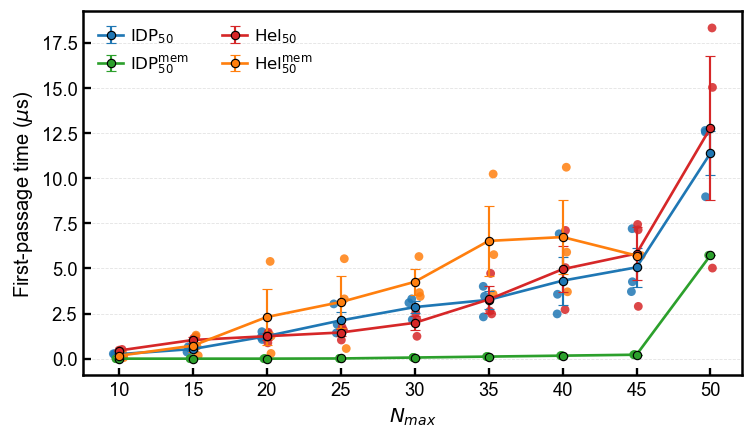

四组 FPT 明细已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/four_group_fpt_records.csv
四组 FPT 汇总已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/four_group_fpt_summary.csv
四组 FPT 组间差异已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/four_group_fpt_pairwise.csv
四组 FPT 图已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/four_group_fpt_threshold_trend.png


In [15]:
# ================= 四组比较：无膜 + 有膜 的 First-passage time =================
# 独立新增 cell：保留上面两个现有图和统计结果，只额外输出四组 FPT 统计/绘图。

from pathlib import Path
import itertools
import csv

import numpy as np
import matplotlib.pyplot as plt

required = [
    'GROUP_1_NAME', 'GROUP_1_FILES', 'GROUP_1_COLOR',
    'GROUP_2_NAME', 'GROUP_2_FILES', 'GROUP_2_COLOR',
    'RESULT_DIR', 'FPT_THRESHOLDS', 'FPT_SMOOTH_WINDOW_US',
    'KINETICS_RANDOM_SEED', 'KINETICS_BOOTSTRAP_N',
    'smooth_fpt_by_time', 'fpt_first_crossing_time', 'load_cluster_trace',
    'bootstrap_mean_diff', 'exact_permutation_pvalue', 'CUTOFF_DISTANCE',
    'show_table', 'write_csv', 'new_subplots', 'savefig_pub',
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError('请先运行前面的样式、轨迹配置和 kinetics 分析 cell: ' + ', '.join(missing))

# ---------------- 用户可调参数 ----------------
FOUR_GROUP_FPT_THRESHOLDS = list(FPT_THRESHOLDS)
FOUR_GROUP_FPT_SMOOTH_WINDOW_US = FPT_SMOOTH_WINDOW_US
FOUR_GROUP_BOOTSTRAP_N = KINETICS_BOOTSTRAP_N
FOUR_GROUP_RANDOM_SEED = KINETICS_RANDOM_SEED
FOUR_GROUP_SAVE_DPI = 600
FOUR_GROUP_FIG_PRESET = 'double_medium'

# cluster_info.txt 来自 TR_Mdvwhole/pbc.xtc；gmx check 显示 timestep = 1000 ps = 0.001 us。
MEM_CLUSTER_INFO_DT_US = 0.001
MEM_RESIDUES_PER_CHAIN = 140
MEM_SELECTION_CRITERIA = 'protein and not name H*'

ONMEM_BASE = Path('/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Onmem/muti_chain/POPC7-POPG3')


def _onmem_item(replica_name):
    tr_dir = ONMEM_BASE / replica_name / 'TR_Mdvwhole'
    return {
        'tpr': str(tr_dir / 'pbc.tpr'),
        'xtc': str(tr_dir / 'clus_centered.xtc'),
        'cluster_info': str(tr_dir / 'cluster_info.txt'),
        'save_name': f'onmem_{replica_name}.txt',
    }


FOUR_GROUPS = [
    {
        'name': GROUP_1_NAME,
        'plain_name': 'IDP50_no_membrane',
        'files': GROUP_1_FILES,
        'color': GROUP_1_COLOR,
        'source': 'existing_txt_or_trajectory',
    },
    {
        'name': r'$\mathrm{IDP}_{50}^{\mathrm{mem}}$',
        'plain_name': 'IDP50_membrane',
        'files': [_onmem_item(rep) for rep in ['alhx_0_plus1', 'alhx_0_plus2', 'alhx_0_plus3']],
        'color': '#2ca02c',
        'source': 'membrane_cluster_info_or_trajectory',
    },
    {
        'name': GROUP_2_NAME,
        'plain_name': 'Hel50_no_membrane',
        'files': GROUP_2_FILES,
        'color': GROUP_2_COLOR,
        'source': 'existing_txt_or_trajectory',
    },
    {
        'name': r'$\mathrm{Hel}_{50}^{\mathrm{mem}}$',
        'plain_name': 'Hel50_membrane',
        'files': [_onmem_item(rep) for rep in ['alhx_700_WALL1', 'alhx_700_WALL2', 'alhx_700_WALL3']],
        'color': '#ff7f0e',
        'source': 'membrane_cluster_info_or_trajectory',
    },
]


def _read_trace_cache(path):
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    header = path.read_text(errors='ignore').splitlines()[0] if path.exists() else ''
    time = data[:, 0].astype(float)
    if 'Time(ns)' in header or np.nanmax(time) > 100:
        time = time / 1000.0

    size = data[:, 1].astype(float)
    order = np.argsort(time)
    return time[order], size[order]


def _read_membrane_cluster_info(path, dt_us=MEM_CLUSTER_INFO_DT_US):
    data = np.loadtxt(path, skiprows=1)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    frame = data[:, 0].astype(float)
    max_cluster_size = data[:, 2].astype(float)
    time_us = (frame - 1.0) * dt_us
    order = np.argsort(time_us)
    return time_us[order], max_cluster_size[order]


def _save_trace_cache(path, time_us, size):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savetxt(
        path,
        np.column_stack((np.asarray(time_us) * 1000.0, np.asarray(size))),
        fmt='%.4f',
        header='Time(ns) Max_Cluster_Size',
    )


def _analyze_membrane_trajectory(item, save_path):
    if 'mda' not in globals() or 'distance_array' not in globals() or 'find_clusters' not in globals():
        raise RuntimeError('缺少 MDAnalysis 相关函数；请先运行前面的轨迹分析 cell，或先生成 cluster_info.txt。')

    print(f"  -> [膜体系重新计算] {Path(item['xtc']).name}")
    u = mda.Universe(item['tpr'], item['xtc'])

    protein_residues = u.select_atoms('protein').residues
    if len(protein_residues) % MEM_RESIDUES_PER_CHAIN != 0:
        raise ValueError(
            f"蛋白残基数 {len(protein_residues)} 不能被 {MEM_RESIDUES_PER_CHAIN} 整除，"
            '请检查 MEM_RESIDUES_PER_CHAIN 或 protein selection。'
        )

    num_chains = len(protein_residues) // MEM_RESIDUES_PER_CHAIN
    protein_chains = []
    for chain_idx in range(num_chains):
        start = chain_idx * MEM_RESIDUES_PER_CHAIN
        stop = (chain_idx + 1) * MEM_RESIDUES_PER_CHAIN
        protein_chains.append(protein_residues[start:stop].atoms)

    chain_selections = [chain.select_atoms(MEM_SELECTION_CRITERIA) for chain in protein_chains]
    times_ns = []
    sizes = []
    n_frames = len(u.trajectory)

    for frame_idx, ts in enumerate(u.trajectory):
        adj = np.zeros((num_chains, num_chains), dtype=bool)
        for i in range(num_chains):
            pos_i = chain_selections[i].positions
            if len(pos_i) == 0:
                continue
            for j in range(i + 1, num_chains):
                pos_j = chain_selections[j].positions
                if len(pos_j) and np.any(distance_array(pos_i, pos_j) < CUTOFF_DISTANCE):
                    adj[i, j] = adj[j, i] = True

        clusters = find_clusters(adj)
        sizes.append(max(len(cluster) for cluster in clusters) if clusters else 0)
        times_ns.append(ts.time / 1000.0)

        if frame_idx % 100 == 0:
            print(f"    Frame {frame_idx}/{n_frames} | Size: {sizes[-1]}", end='\r')

    print('')
    time_us = np.asarray(times_ns) / 1000.0
    size = np.asarray(sizes, dtype=float)
    _save_trace_cache(save_path, time_us, size)
    return time_us, size, save_path


def _load_four_group_trace(item, use_membrane_loader=False):
    cache_path = RESULT_DIR / Path(item['save_name']).name
    if cache_path.exists():
        time, size = _read_trace_cache(cache_path)
        return time, size, cache_path

    if use_membrane_loader:
        cluster_info = Path(item.get('cluster_info', ''))
        if cluster_info.exists():
            time, size = _read_membrane_cluster_info(cluster_info)
            _save_trace_cache(cache_path, time, size)
            return time, size, cluster_info
        return _analyze_membrane_trajectory(item, cache_path)

    return load_cluster_trace(item)


def _fpt_values(records, group_name, threshold):
    values = [r['fpt_us'] for r in records if r['group'] == group_name and r['threshold'] == threshold]
    return np.asarray([value for value in values if np.isfinite(value)], dtype=float)


def _mean_sd_sem(values):
    values = np.asarray(values, dtype=float)
    mean = float(np.mean(values)) if len(values) else np.nan
    sd = float(np.std(values, ddof=1)) if len(values) > 1 else np.nan
    sem = float(sd / np.sqrt(len(values))) if len(values) > 1 else np.nan
    return mean, sd, sem


def _write_records(path, records, columns):
    with open(path, 'w', newline='') as fh:
        writer = csv.DictWriter(fh, fieldnames=columns)
        writer.writeheader()
        for record in records:
            writer.writerow({column: record.get(column, '') for column in columns})


four_group_trace_records = []
four_group_fpt_records = []

for group in FOUR_GROUPS:
    use_membrane_loader = group['source'] == 'membrane_cluster_info_or_trajectory'
    for rep_idx, item in enumerate(group['files'], start=1):
        time, size, source_path = _load_four_group_trace(item, use_membrane_loader=use_membrane_loader)
        smoothed = smooth_fpt_by_time(time, size, FOUR_GROUP_FPT_SMOOTH_WINDOW_US)

        four_group_trace_records.append({
            'group': group['name'],
            'plain_group': group['plain_name'],
            'replicate': f'Run {rep_idx}',
            'source_path': str(source_path),
            'time': time,
            'size': size,
        })

        for threshold in FOUR_GROUP_FPT_THRESHOLDS:
            four_group_fpt_records.append({
                'group': group['name'],
                'plain_group': group['plain_name'],
                'replicate': f'Run {rep_idx}',
                'threshold': threshold,
                'fpt_us': fpt_first_crossing_time(time, smoothed, threshold),
                'source_path': str(source_path),
            })


four_group_fpt_summary = []
for threshold in FOUR_GROUP_FPT_THRESHOLDS:
    for group in FOUR_GROUPS:
        values = _fpt_values(four_group_fpt_records, group['name'], threshold)
        mean, sd, sem = _mean_sd_sem(values)
        four_group_fpt_summary.append({
            'threshold': threshold,
            'group': group['name'],
            'plain_group': group['plain_name'],
            'n': len(values),
            'mean_fpt_us': mean,
            'sd_fpt_us': sd,
            'sem_fpt_us': sem,
            'median_fpt_us': float(np.median(values)) if len(values) else np.nan,
            'min_fpt_us': float(np.min(values)) if len(values) else np.nan,
            'max_fpt_us': float(np.max(values)) if len(values) else np.nan,
        })


four_group_fpt_pairwise = []
for threshold in FOUR_GROUP_FPT_THRESHOLDS:
    for group_1, group_2 in itertools.combinations(FOUR_GROUPS, 2):
        values_1 = _fpt_values(four_group_fpt_records, group_1['name'], threshold)
        values_2 = _fpt_values(four_group_fpt_records, group_2['name'], threshold)
        delta_mean, delta_low, delta_high = bootstrap_mean_diff(
            values_1,
            values_2,
            n_boot=FOUR_GROUP_BOOTSTRAP_N,
            seed=FOUR_GROUP_RANDOM_SEED + int(threshold),
        )
        four_group_fpt_pairwise.append({
            'threshold': threshold,
            'comparison': f"{group_2['plain_name']} - {group_1['plain_name']}",
            'group_1': group_1['plain_name'],
            'group_2': group_2['plain_name'],
            'group_1_n': len(values_1),
            'group_2_n': len(values_2),
            'delta_mean_fpt_us': delta_mean,
            'delta_2.5%_fpt_us': delta_low,
            'delta_97.5%_fpt_us': delta_high,
            'exact_perm_p': exact_permutation_pvalue(values_1, values_2),
        })


fpt_record_columns = ['plain_group', 'group', 'replicate', 'threshold', 'fpt_us', 'source_path']
fpt_summary_columns = [
    'threshold', 'plain_group', 'group', 'n',
    'mean_fpt_us', 'sd_fpt_us', 'sem_fpt_us', 'median_fpt_us', 'min_fpt_us', 'max_fpt_us',
]
fpt_pairwise_columns = [
    'threshold', 'comparison', 'group_1_n', 'group_2_n',
    'delta_mean_fpt_us', 'delta_2.5%_fpt_us', 'delta_97.5%_fpt_us', 'exact_perm_p',
]

_write_records(RESULT_DIR / 'four_group_fpt_records.csv', four_group_fpt_records, fpt_record_columns)
_write_records(RESULT_DIR / 'four_group_fpt_summary.csv', four_group_fpt_summary, fpt_summary_columns)
_write_records(RESULT_DIR / 'four_group_fpt_pairwise.csv', four_group_fpt_pairwise, fpt_pairwise_columns)

show_table(four_group_fpt_summary, fpt_summary_columns, title='Four-group FPT summary across Nmax thresholds')
show_table(four_group_fpt_pairwise, fpt_pairwise_columns, title='Four-group pairwise FPT differences: group_2 - group_1')


def plot_four_group_fpt_threshold_trend(ax):
    rng = np.random.default_rng(FOUR_GROUP_RANDOM_SEED)
    thresholds = np.asarray(FOUR_GROUP_FPT_THRESHOLDS, dtype=float)
    offsets = np.linspace(-0.32, 0.32, len(FOUR_GROUPS))

    for group, offset in zip(FOUR_GROUPS, offsets):
        means = []
        sems = []
        for threshold in FOUR_GROUP_FPT_THRESHOLDS:
            values = _fpt_values(four_group_fpt_records, group['name'], threshold)
            mean, sd, sem = _mean_sd_sem(values)
            means.append(mean)
            sems.append(sem if np.isfinite(sem) else 0.0)

            if len(values):
                jitter = rng.normal(0, 0.055, size=len(values))
                ax.scatter(
                    np.full(len(values), threshold + offset) + jitter,
                    values,
                    s=28,
                    color=group['color'],
                    alpha=0.85,
                    edgecolors='none',
                    zorder=3,
                )

        ax.errorbar(
            thresholds,
            means,
            yerr=sems,
            fmt='o-',
            color=group['color'],
            ecolor=group['color'],
            capsize=3,
            lw=1.6,
            elinewidth=1.3,
            capthick=1.3,
            ms=5,
            markeredgecolor='black',
            markeredgewidth=0.7,
            label=group['name'],
            zorder=5,
        )

    ax.set_xlabel(r'$N_{max}$')
    ax.set_ylabel(r'First-passage time ($\mu$s)')
    ax.set_xticks(FOUR_GROUP_FPT_THRESHOLDS)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
    ax.legend(frameon=False, ncol=2)


fig_four_group_fpt, ax_four_group_fpt = new_subplots(1, 1, preset=FOUR_GROUP_FIG_PRESET)
if isinstance(ax_four_group_fpt, np.ndarray):
    ax_four_group_fpt = np.ravel(ax_four_group_fpt)[0]

plot_four_group_fpt_threshold_trend(ax_four_group_fpt)

four_group_fpt_fig_path = RESULT_DIR / 'four_group_fpt_threshold_trend.png'
savefig_pub(fig_four_group_fpt, four_group_fpt_fig_path, dpi=FOUR_GROUP_SAVE_DPI, tight=True)
plt.show()

print(f'四组 FPT 明细已保存到: {RESULT_DIR / "four_group_fpt_records.csv"}')
print(f'四组 FPT 汇总已保存到: {RESULT_DIR / "four_group_fpt_summary.csv"}')
print(f'四组 FPT 组间差异已保存到: {RESULT_DIR / "four_group_fpt_pairwise.csv"}')
print(f'四组 FPT 图已保存到: {four_group_fpt_fig_path}')


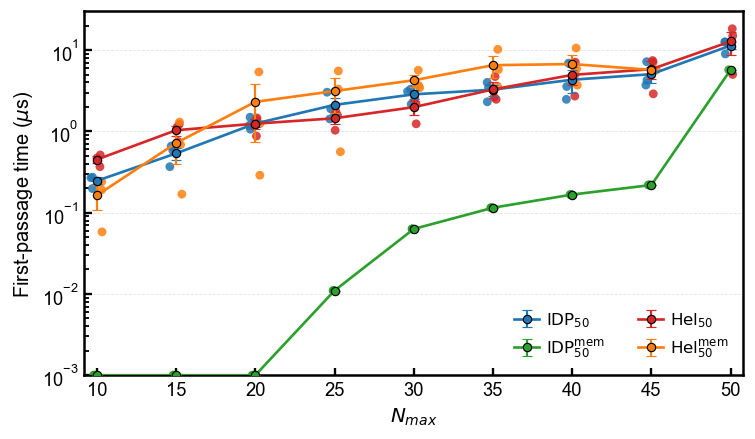

四组 FPT log-scale 图已保存到: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/largclus/four_group_fpt_threshold_trend_log.png


In [16]:
required = [
    'four_group_fpt_records',
    'FOUR_GROUPS',
    'FOUR_GROUP_FPT_THRESHOLDS',
    'FOUR_GROUP_RANDOM_SEED',
    '_fpt_values',
    'new_subplots',
    'savefig_pub',
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError('请先运行前面的四组 FPT cell: ' + ', '.join(missing))


def _log_display_floor(records):
    positive = np.asarray(
        [r['fpt_us'] for r in records if np.isfinite(r['fpt_us']) and r['fpt_us'] > 0],
        dtype=float,
    )
    if len(positive) == 0:
        return 1e-3
    min_positive = float(np.min(positive))
    floor = 10 ** (np.floor(np.log10(min_positive)) - 1)
    return max(floor, 1e-3)


def plot_four_group_fpt_threshold_trend_log(ax):
    floor = _log_display_floor(four_group_fpt_records)
    rng = np.random.default_rng(FOUR_GROUP_RANDOM_SEED)
    thresholds = np.asarray(FOUR_GROUP_FPT_THRESHOLDS, dtype=float)
    offsets = np.linspace(-0.32, 0.32, len(FOUR_GROUPS))

    for group, offset in zip(FOUR_GROUPS, offsets):
        means = []
        lower_err = []
        upper_err = []
        for threshold in FOUR_GROUP_FPT_THRESHOLDS:
            values = _fpt_values(four_group_fpt_records, group['name'], threshold)
            if len(values):
                display_values = np.where(np.isfinite(values) & (values > 0), values, floor)
                mean = float(np.mean(values))
                sem = float(np.std(values, ddof=1) / np.sqrt(len(values))) if len(values) > 1 else 0.0
                display_mean = max(mean, floor)
                display_low = max(mean - sem, floor)
                display_high = max(mean + sem, floor)
                means.append(display_mean)
                lower_err.append(display_mean - display_low)
                upper_err.append(display_high - display_mean)
                jitter = rng.normal(0, 0.055, size=len(values))
                ax.scatter(
                    np.full(len(values), threshold + offset) + jitter,
                    display_values,
                    s=28,
                    color=group['color'],
                    alpha=0.85,
                    edgecolors='none',
                    zorder=3,
                )
            else:
                means.append(np.nan)
                lower_err.append(0.0)
                upper_err.append(0.0)

        ax.errorbar(
            thresholds,
            means,
            yerr=np.vstack([lower_err, upper_err]),
            fmt='o-',
            color=group['color'],
            ecolor=group['color'],
            capsize=3,
            lw=1.6,
            elinewidth=1.3,
            capthick=1.3,
            ms=5,
            markeredgecolor='black',
            markeredgewidth=0.7,
            label=group['name'],
            zorder=5,
        )

    ax.set_yscale('log')
    ax.set_xlabel(r'$N_{max}$')
    ax.set_ylabel(r'First-passage time ($\mu$s)')
    ax.set_xticks(FOUR_GROUP_FPT_THRESHOLDS)
    ax.set_xlim(min(FOUR_GROUP_FPT_THRESHOLDS) - 0.8, max(FOUR_GROUP_FPT_THRESHOLDS) + 0.8)
    ax.set_ylim(bottom=floor)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
    ax.legend(frameon=False, ncol=2)


fig_four_group_fpt_log, ax_four_group_fpt_log = new_subplots(1, 1, preset=FOUR_GROUP_FIG_PRESET)
if isinstance(ax_four_group_fpt_log, np.ndarray):
    ax_four_group_fpt_log = np.ravel(ax_four_group_fpt_log)[0]

plot_four_group_fpt_threshold_trend_log(ax_four_group_fpt_log)
four_group_fpt_log_fig_path = RESULT_DIR / 'four_group_fpt_threshold_trend_log.png'
savefig_pub(fig_four_group_fpt_log, four_group_fpt_log_fig_path, dpi=FOUR_GROUP_SAVE_DPI, tight=True)
plt.show()
print(f'四组 FPT log-scale 图已保存到: {four_group_fpt_log_fig_path}')